In [1]:
import pickle
import random
import torch
from tqdm import tqdm
from minf.data import FieldDataset
from minf.models import Decoder, SirenNetUnbatched
from minf.utils import plot_field
from minf.metamol import Metamol
from minf.models.utils import get_grid
from torch.utils.data import DataLoader
import numpy as np
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [2]:
resolution = 32

pdb_file = "../data/6ega_protein.pdb"
sdf_file = "../data/6ega_ligand.sdf"

properties = [
    "wigner_seitz_electron_density",
]

mmol, _ = Metamol.from_complex(pdb_file, sdf_file, size=resolution, properties=properties, b=0.25)

[21:08:07] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


In [3]:
mmol.calculate_field()
vector_field = mmol.to_vector_field()[:, :, :, [0, 1, 9, 11, 12, 18]]

In [4]:
rot=2.9
# plot_field(vector_field[:, :, :, 2], cam_rotate=rot, resolution=1024).save("ligand.png")
# plot_field(vector_field[:, :, :, 5], cam_rotate=rot, resolution=1024).save("protein.png")

In [5]:
net = SirenNetUnbatched(
    dim_in=4,
    dim_hidden=256,
    dim_out=1,
    num_layers=8,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

decoder = Decoder(
    net,
    # output_shape=[resolution, resolution, resolution, 24, 1],
    output_shape=[resolution, resolution, resolution, 6, 1],
    latent_dim=128,
    n_shapes=1
)

decoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=decoder.parameters())

decoder.load_state_dict(torch.load("../models/reconstruction_model_better.pt", weights_only=True))
decoder.cuda()

/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Decoder(
  (net): SirenNetUnbatched(
    (layers): ModuleList(
      (0-7): 8 x Siren(
        (activation): Sine()
      )
    )
    (last_layer): Siren(
      (activation): Identity()
    )
  )
  (modulator): ModulatorUnbatched(
    (layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): ReLU()
      )
      (1-7): 7 x Sequential(
        (0): Linear(in_features=384, out_features=256, bias=True)
        (1): ReLU()
      )
    )
  )
)

In [6]:
min_loss = 9999999
for epoch in (pbar := tqdm(range(20000))):
    loss = decoder(vector_field.cuda(), latent_idx=0)
    optim.zero_grad()
    loss.backward()
    optim.step()
    if loss.item() < min_loss:
        min_loss = loss.item()
        torch.save(decoder.state_dict(), "reconstruction_model.pt")
        
    pbar.set_description(f"Epoch {epoch} (loss: {loss.item()})")
    continue
    
    if epoch % 100 == 0:
        try: 
            reconstructed = decoder.predict(decoder.latents[0].cuda())
            reconstructed = reconstructed.cpu().detach().squeeze(-1)
            plot_field(reconstructed[:, :, :, 0], cam_rotate=rot, resolution=1024).save(f"ligand_{epoch:07d}.png")
            plot_field(reconstructed[:, :, :, 5], cam_rotate=rot, resolution=1024).save(f"protein_{epoch:07d}.png")
        except Exception:
            ...

Epoch 26 (loss: 0.017479408532381058):   0%|                                                              | 27/20000 [00:03<40:23,  8.24it/s]


KeyboardInterrupt: 

In [6]:
def calculate_psnr(original, compressed):
    original = original.astype(np.float32)
    compressed = compressed.astype(np.float32)
    
    mse = np.mean((original - compressed) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

yt : [INFO     ] 2025-02-11 21:08:32,731 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 21:08:32,731 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 21:08:32,731 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 21:08:32,731 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 21:08:32,732 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 21:08:32,792 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 21:08:32,799 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 21:08:32,801 Creating volume
yt : [INFO     ] 2025-02-11 21:08:32,816 Creating transfer function
yt : [INFO     ] 2025-02-11 21:08:32,816 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


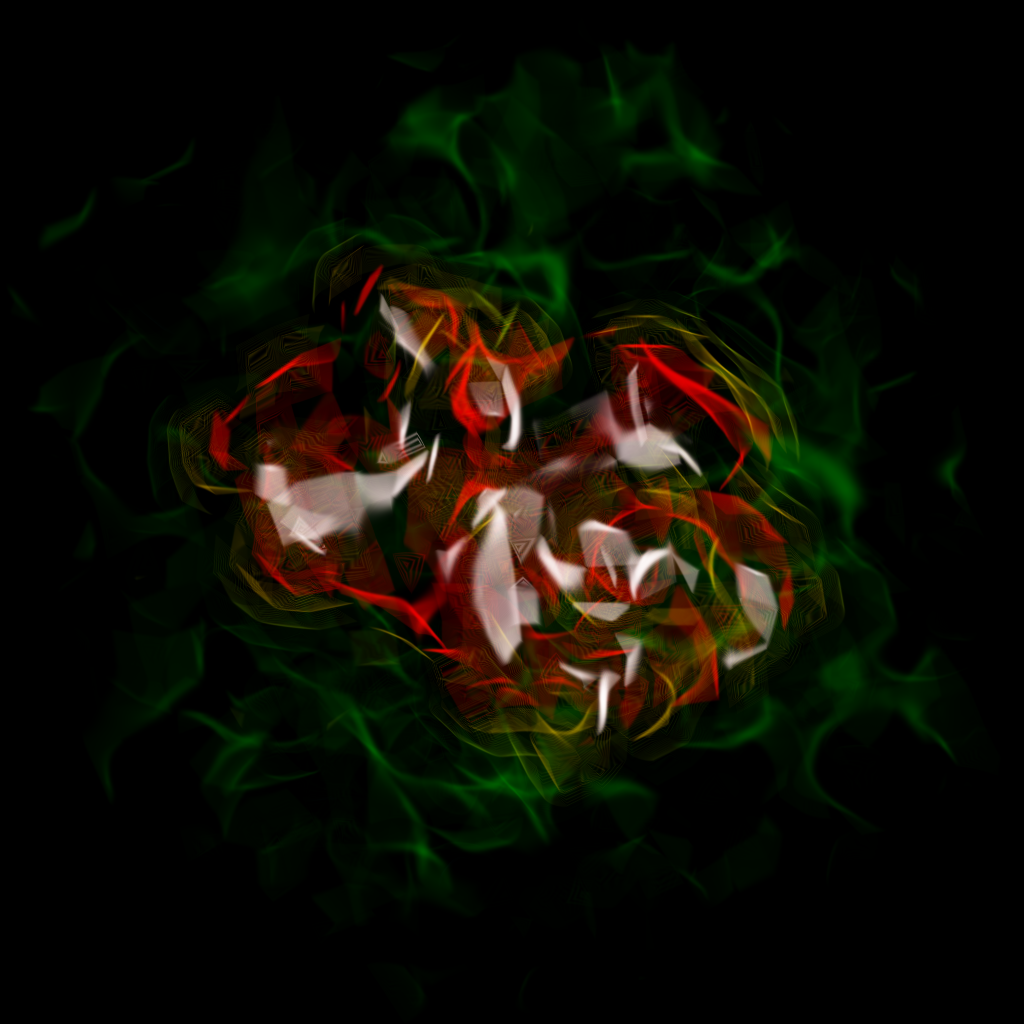

yt : [INFO     ] 2025-02-11 21:08:33,395 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 21:08:33,402 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 21:08:33,402 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 21:08:33,402 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 21:08:33,403 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 21:08:33,443 Setting default field to ('gas', 'density')
yt : [WARNING  ] 2025-02-11 21:08:33,449 No previously rendered image found, rendering now.
yt : [INFO     ] 2025-02-11 21:08:33,450 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 21:08:33,450 Creating volume
yt : [INFO     ] 2025-02-11 21:08:33,465 Creating transfer function
yt : [INFO     ] 2025-02-11 21:08:33,466 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.
yt : [INFO     ] 2025-02-11 21:08:3

ValueError: operands could not be broadcast together with shapes (32,32,32,6) (16,16,16,6) 

In [8]:

superres = [16, 16, 16, 6]
coords = get_grid(superres).cuda()

reconstructed = decoder(None, latent_idx=0, coords=coords, output_shape=superres)
#reconstructed = decoder.predict(decoder.latents[0].cuda())
reconstructed = reconstructed.cpu().detach().squeeze(-1)
plot_field(reconstructed[:, :, :, 5], cam_rotate=rot, resolution=1024).show()
plot_field(reconstructed[:, :, :, 2], cam_rotate=rot, resolution=1024).save("ligand.png")

calculate_psnr(vector_field.cpu().detach().numpy(), reconstructed.numpy())